# DDQN

In [ ]:
!pip install torch 

Class Ratio Summary
Train | n=2054 | class0=1859 (90.51%) | class1= 195 (9.49%) | c1/c0=0.1049
ValTun | n= 616 | class0= 540 (87.66%) | class1=  76 (12.34%) | c1/c0=0.1407
ValSel | n= 616 | class0= 530 (86.04%) | class1=  86 (13.96%) | c1/c0=0.1623
 Test | n= 822 | class0= 730 (88.81%) | class1=  92 (11.19%) | c1/c0=0.1260
Data Split Information
Total samples: 4108
Train set: 2054 samples (50.0%)
  - Class 0: 1859, Class 1: 195
Valid(Tune) set: 616 samples
  - Class 0: 540, Class 1: 76
Valid(Select) set: 616 samples
  - Class 0: 530, Class 1: 86
Test set: 822 samples (20.0%)
  - Class 0: 730, Class 1: 92

Class ratio (train set): 0.1049

HYPERPARAMETER GRID SEARCH (Total: 54 combinations)

[1/54] γ=0.90, lr=1e-04, ε=0.990, bs=32
  Ep  20 | Tune G-mean: 0.4019 (Sens: 0.1711, Spec: 0.9444) | Best: 0.4039
  Ep  40 | Tune G-mean: 0.2990 (Sens: 0.0921, Spec: 0.9704) | Best: 0.4450
  Ep  60 | Tune G-mean: 0.3390 (Sens: 0.1184, Spec: 0.9704) | Best: 0.4450
  Ep  80 | Tune G-mean: 0.3004 (Sens

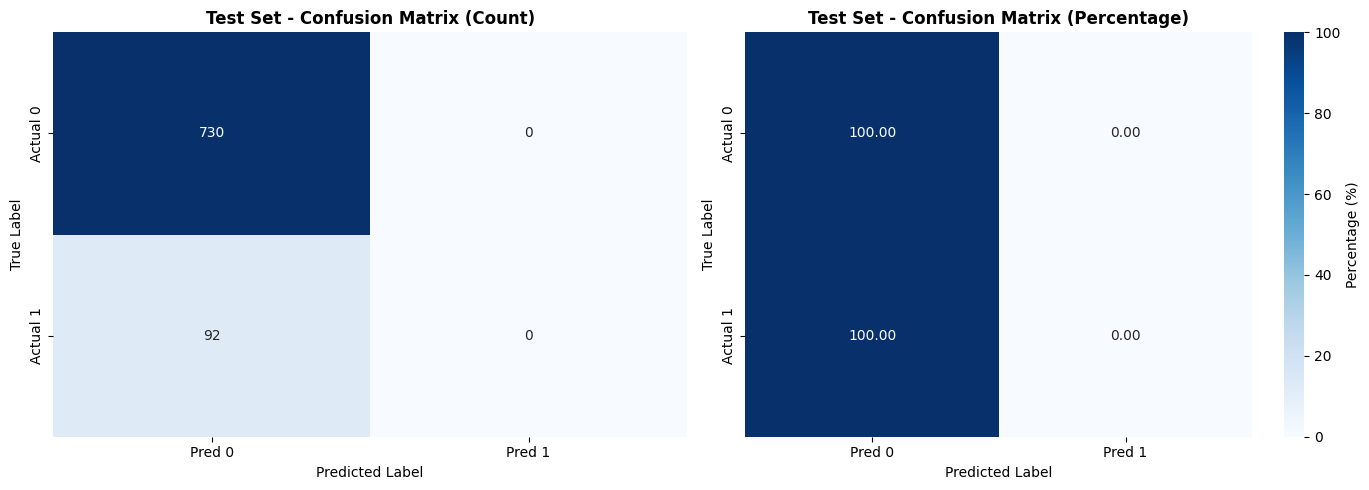


상세 메트릭 (Test Set):
Sensitivity (Recall for Class 1): 0.0000
Specificity (Recall for Class 0): 1.0000
Precision (Class 1): 0.0000
F1-Score: 0.0000

VALIDATION SET vs TEST SET 성능 비교

Validation(Selection) Set - G-mean: 0.0000
Test Set - G-mean: 0.0000
Difference (Valid - Test): 0.0000

Validation Confusion Matrix:
[[530   0]
 [ 86   0]]

Test Confusion Matrix:
[[730   0]
 [ 92   0]]


In [ ]:
import random
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# boruta에서 선택된 데이터 불러오기
dat = pd.read_csv("../../data/processed/data_selected.csv", index_col=0)

# 시드 설정
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2 layers (96, 64)
# data_selected.csv의 데이터 수를 고려할 때 과적합이 발생할 수 있으나 valid/test의 성능 지표를 확인하고 고려하도록 하자
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 96),
            nn.ReLU(),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )
         

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))

        return (
            torch.FloatTensor(states).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones.astype(np.float32)).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)


class DDQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.95,
        lr=5e-4,
        batch_size=64,
        memory_size=100_000,
        target_update=500,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.online_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(memory_size)

        self.total_steps = 0

    def act(self, state, epsilon: float = None):
        if epsilon is None:
            epsilon = self.epsilon

        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        q_values = self.online_net(states).gather(1, actions)

        next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
        next_q_values = self.target_net(next_states).gather(1, next_actions)

        target_q = rewards + (1 - dones) * self.gamma * next_q_values

        loss = F.mse_loss(q_values, target_q.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.total_steps += 1
        if self.total_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return float(loss.item())


# ---- 데이터 준비 (Train/Valid/Test Split 먼저, 그 후 Scaling) ----
from sklearn.preprocessing import MinMaxScaler

risk_label_col = "Risk_Label"

feature_cols = [c for c in dat.select_dtypes(include=[np.number]).columns if c != risk_label_col]
if len(feature_cols) == 0:
    raise ValueError("학습에 사용할 수치형 feature가 없습니다.")

risk_label_data = dat[risk_label_col].fillna(0).astype(int).to_numpy()
feature_data_raw = dat[feature_cols].fillna(0.0).to_numpy()
n_steps = len(dat)

train_ratio, valid_ratio, test_ratio = 0.5, 0.3, 0.2
n_train = int(n_steps * train_ratio)
n_valid = int(n_steps * valid_ratio)

train_indices = np.arange(0, n_train)
valid_indices = np.arange(n_train, n_train + n_valid)
test_indices = np.arange(n_train + n_valid, n_steps)

train_feature_raw = feature_data_raw[train_indices]
train_label = risk_label_data[train_indices]

valid_feature_raw = feature_data_raw[valid_indices]
valid_label = risk_label_data[valid_indices]
if len(valid_label) < 2:
    raise ValueError("Validation set 길이가 너무 짧아 tuning/selection 분할이 불가능합니다. split 비율을 조정하세요.")
valid_split_point = len(valid_label) // 2
valid_tune_feature_raw = valid_feature_raw[:valid_split_point]
valid_tune_label = valid_label[:valid_split_point]
valid_select_feature_raw = valid_feature_raw[valid_split_point:]
valid_select_label = valid_label[valid_split_point:]

test_feature_raw = feature_data_raw[test_indices]
test_label = risk_label_data[test_indices]

def summarize_class_ratio(name, y):
    n_total = len(y)
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    r0 = n0 / n_total if n_total > 0 else 0.0
    r1 = n1 / n_total if n_total > 0 else 0.0
    imbalance = (n1 / max(n0, 1)) if n_total > 0 else 0.0
    print(f"{name:>5} | n={n_total:4d} | class0={n0:4d} ({r0:.2%}) | class1={n1:4d} ({r1:.2%}) | c1/c0={imbalance:.4f}")
    if n0 == 0 or n1 == 0:
        raise ValueError(f"{name} set에 클래스 0 또는 1이 없습니다. split 비율 또는 기간을 조정하세요.")

print("Class Ratio Summary")
summarize_class_ratio("Train", train_label)
summarize_class_ratio("ValTun", valid_tune_label)
summarize_class_ratio("ValSel", valid_select_label)
summarize_class_ratio("Test", test_label)

scaler = MinMaxScaler()
scaler.fit(train_feature_raw)

train_feature = scaler.transform(train_feature_raw).astype(np.float32)
valid_tune_feature = scaler.transform(valid_tune_feature_raw).astype(np.float32)
valid_select_feature = scaler.transform(valid_select_feature_raw).astype(np.float32)
test_feature = scaler.transform(test_feature_raw).astype(np.float32)

print("=" * 60)
print("Data Split Information")
print("=" * 60)
print(f"Total samples: {n_steps}")
print(f"Train set: {len(train_indices)} samples ({train_ratio*100:.1f}%)")
print(f"  - Class 0: {(train_label==0).sum()}, Class 1: {(train_label==1).sum()}")
print(f"Valid(Tune) set: {len(valid_tune_label)} samples")
print(f"  - Class 0: {(valid_tune_label==0).sum()}, Class 1: {(valid_tune_label==1).sum()}")
print(f"Valid(Select) set: {len(valid_select_label)} samples")
print(f"  - Class 0: {(valid_select_label==0).sum()}, Class 1: {(valid_select_label==1).sum()}")
print(f"Test set: {len(test_indices)} samples ({test_ratio*100:.1f}%)")
print(f"  - Class 0: {(test_label==0).sum()}, Class 1: {(test_label==1).sum()}")

n_negative = (train_label == 0).sum()
n_positive = (train_label == 1).sum()
class_ratio = n_positive / max(n_negative, 1)

print(f"\nClass ratio (train set): {class_ratio:.4f}")
print("=" * 60)

state_dim = len(feature_cols)
action_dim = 2


def compute_reward(action, actual_label, class_ratio):
    action = int(action)
    actual_label = int(actual_label)
    
    if actual_label == 0:
        if action == 0:
            return class_ratio
        else:
            return -class_ratio
    else:
        if action == 1:
            return 1.0
        else:
            return -1.0


# ---- Validation 기반 하이퍼파라미터 Grid Search ----
from itertools import product
from sklearn.metrics import confusion_matrix

param_grid = {
    'gamma': [0.9, 0.95, 0.99],
    'lr': [1e-4, 5e-4, 1e-3],
    'epsilon_decay': [0.99, 0.995, 0.999],
    'batch_size': [32, 64],
}

def compute_gmean(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    gmean = float(np.sqrt(sensitivity * specificity))
    return gmean, sensitivity, specificity

grid_search_results = []
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print("\n" + "=" * 80)
print(f"HYPERPARAMETER GRID SEARCH (Total: {len(param_combinations)} combinations)")
print("=" * 80)

patience = 15
min_episodes = 40
best_overall_select_gmean = 0.0
best_overall_params = None

for idx, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    gamma, lr, epsilon_decay, batch_size = params
    
    print(f"\n[{idx+1}/{len(param_combinations)}] γ={gamma:.2f}, lr={lr:.0e}, ε={epsilon_decay:.3f}, bs={batch_size}")
    
    agent_tune = DDQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=gamma,
        lr=lr,
        batch_size=batch_size,
        memory_size=50_000,
        target_update=200,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=epsilon_decay,
    )
    
    episodes_tune = 100
    max_steps_tune = 500
    best_tune_gmean = 0.0
    patience_counter = 0
    
    for ep in range(1, episodes_tune + 1):
        start_idx = np.random.randint(0, len(train_indices) - max_steps_tune - 1)
        episode_reward = 0.0
        
        for i in range(max_steps_tune):
            state = train_feature[start_idx + i]
            next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_indices) else train_feature[start_idx + i]
            actual_label = train_label[start_idx + i]
            
            action = agent_tune.act(state)
            reward = compute_reward(action, actual_label, class_ratio)
            done = i == (max_steps_tune - 1)
            
            agent_tune.memory.push(state, action, reward, next_state, done)
            _ = agent_tune.update()
            episode_reward += reward
        
        agent_tune.decay_epsilon()
        
        if ep % 5 == 0:
            agent_tune.online_net.eval()
            valid_pred = []
            with torch.no_grad():
                for t in range(len(valid_tune_label)):
                    state = valid_tune_feature[t]
                    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    q_values = agent_tune.online_net(state_t)
                    action = int(torch.argmax(q_values, dim=1).item())
                    valid_pred.append(action)
            
            valid_pred = np.array(valid_pred)
            tune_gmean, tune_sensitivity, tune_specificity = compute_gmean(valid_tune_label, valid_pred)
            agent_tune.online_net.train()
            
            if tune_gmean > best_tune_gmean:
                best_tune_gmean = tune_gmean
                patience_counter = 0
            else:
                patience_counter += 1
            
            if ep % 20 == 0:
                print(f"  Ep {ep:3d} | Tune G-mean: {tune_gmean:.4f} (Sens: {tune_sensitivity:.4f}, Spec: {tune_specificity:.4f}) | Best: {best_tune_gmean:.4f}")
            
            if ep > min_episodes and patience_counter >= patience:
                break

    agent_tune.online_net.eval()
    valid_select_pred = []
    with torch.no_grad():
        for t in range(len(valid_select_label)):
            state = valid_select_feature[t]
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = agent_tune.online_net(state_t)
            action = int(torch.argmax(q_values, dim=1).item())
            valid_select_pred.append(action)
    valid_select_pred = np.array(valid_select_pred)
    select_gmean, select_sensitivity, select_specificity = compute_gmean(valid_select_label, valid_select_pred)
    
    grid_search_results.append({
        'params': param_dict,
        'best_tune_gmean': best_tune_gmean,
        'select_gmean': select_gmean,
        'select_sensitivity': select_sensitivity,
        'select_specificity': select_specificity,
    })
    
    if select_gmean > best_overall_select_gmean:
        best_overall_select_gmean = select_gmean
        best_overall_params = param_dict

grid_search_results.sort(key=lambda x: x['select_gmean'], reverse=True)

print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETERS")
print("=" * 80)
for i, result in enumerate(grid_search_results[:5]):
    print(f"{i+1}. Select G-mean: {result['select_gmean']:.4f} | Tune Best: {result['best_tune_gmean']:.4f} | Params: {result['params']}")

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS")
print("=" * 80)
for k, v in best_overall_params.items():
    print(f"{k}: {v}")
print(f"Best Selection G-mean: {best_overall_select_gmean:.4f}")
print("=" * 80)

# ---- 최적 파라미터로 재학습 ----
print("\nTraining with best hyperparameters...")
agent = DDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gamma=best_overall_params['gamma'],
    lr=best_overall_params['lr'],
    batch_size=best_overall_params['batch_size'],
    memory_size=50_000,
    target_update=200,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=best_overall_params['epsilon_decay'],
)

episodes = 250
max_steps = 500
scores = []
valid_scores = []

for ep in range(1, episodes + 1):
    start_idx = np.random.randint(0, len(train_indices) - max_steps - 1)
    episode_reward = 0.0

    for i in range(max_steps):
        state = train_feature[start_idx + i]
        next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_indices) else train_feature[start_idx + i]
        actual_label = train_label[start_idx + i]

        action = agent.act(state)
        reward = compute_reward(action, actual_label, class_ratio)
        done = i == (max_steps - 1)

        agent.memory.push(state, action, reward, next_state, done)
        _ = agent.update()
        episode_reward += reward

    agent.decay_epsilon()
    scores.append(episode_reward)

    if ep % 10 == 0:
        agent.online_net.eval()
        valid_pred = []
        with torch.no_grad():
            for t in range(len(valid_select_label)):
                state = valid_select_feature[t]
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = agent.online_net(state_t)
                action = int(torch.argmax(q_values, dim=1).item())
                valid_pred.append(action)
        
        valid_pred = np.array(valid_pred)
        valid_gmean, valid_sensitivity, valid_specificity = compute_gmean(valid_select_label, valid_pred)
        valid_scores.append(valid_gmean)
        agent.online_net.train()
        
        print(f"Episode {ep:3d} | Train Reward: {np.mean(scores[-10:]):8.5f} | Valid G-mean: {valid_gmean:.4f} (Sens: {valid_sensitivity:.4f}, Spec: {valid_specificity:.4f})")

print("최종 학습 완료")



# ---- Test Set에서 최종 성능 평가 ----
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# agent를 eval 모드로 설정
agent.online_net.eval()

# Test Set에 대해 예측
test_predictions = []
with torch.no_grad():
    for t in range(len(test_indices)):
        state = test_feature[t]
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = agent.online_net(state_t)
        action = int(torch.argmax(q_values, dim=1).item())
        test_predictions.append(action)

test_predictions = np.array(test_predictions)

# Confusion Matrix 계산 (Test Set)
cm_test = confusion_matrix(test_label, test_predictions, labels=[0, 1])

# 분류 메트릭 (Test Set)
tn, fp, fn, tp = cm_test.ravel()
sensitivity_test = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_test = tn / (tn + fp) if (tn + fp) > 0 else 0
gmean_test = np.sqrt(sensitivity_test * specificity_test)

print("\n" + "=" * 60)
print("TEST SET - DDQN 분류 모델 최종 성능 평가")
print("=" * 60)
print(f"\nG-mean: {gmean_test:.4f}")
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nTN: {cm_test[0, 0]}, FP: {cm_test[0, 1]}")
print(f"FN: {cm_test[1, 0]}, TP: {cm_test[1, 1]}")

# 분류 리포트
print(f"\n분류 리포트:")
print(classification_report(test_label, test_predictions, 
                          labels=[0, 1],
                          target_names=['Class 0 (Negative)', 'Class 1 (Positive)'],
                          zero_division=0))

# Confusion Matrix 시각화 (Test Set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Count
ax1 = axes[0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax1.set_title('Test Set - Confusion Matrix (Count)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Confusion Matrix - Percentage
cm_test_row_sums = cm_test.sum(axis=1, keepdims=True)
cm_test_percent = np.divide(cm_test.astype(float), cm_test_row_sums, out=np.zeros_like(cm_test, dtype=float), where=cm_test_row_sums != 0) * 100
ax2 = axes[1]
sns.heatmap(cm_test_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax2,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            cbar_kws={'label': 'Percentage (%)'})
ax2.set_title('Test Set - Confusion Matrix (Percentage)', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 상세 메트릭 계산 (Test Set)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_score = 2 * (precision * sensitivity_test) / (precision + sensitivity_test) if (precision + sensitivity_test) > 0 else 0

print(f"\n상세 메트릭 (Test Set):")
print(f"Sensitivity (Recall for Class 1): {sensitivity_test:.4f}")
print(f"Specificity (Recall for Class 0): {specificity_test:.4f}")
print(f"Precision (Class 1): {precision:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print("=" * 60)

# Valid Set vs Test Set 비교
print("\n" + "=" * 60)
print("VALIDATION SET vs TEST SET 성능 비교")
print("=" * 60)

# Validation Set 재평가
agent.online_net.eval()
valid_predictions = []
with torch.no_grad():
    for t in range(len(valid_select_label)):
        state = valid_select_feature[t]
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = agent.online_net(state_t)
        action = int(torch.argmax(q_values, dim=1).item())
        valid_predictions.append(action)

valid_predictions = np.array(valid_predictions)
cm_valid = confusion_matrix(valid_select_label, valid_predictions, labels=[0, 1])
tn_v, fp_v, fn_v, tp_v = cm_valid.ravel()
sensitivity_valid = tp_v / (tp_v + fn_v) if (tp_v + fn_v) > 0 else 0
specificity_valid = tn_v / (tn_v + fp_v) if (tn_v + fp_v) > 0 else 0
gmean_valid = np.sqrt(sensitivity_valid * specificity_valid)

print(f"\nValidation(Selection) Set - G-mean: {gmean_valid:.4f}")
print(f"Test Set - G-mean: {gmean_test:.4f}")
print(f"Difference (Valid - Test): {gmean_valid - gmean_test:.4f}")
print("\nValidation Confusion Matrix:")
print(cm_valid)
print("\nTest Confusion Matrix:")
print(cm_test)
print("=" * 60)


# ---- Save DDQN checkpoint for VaR_ML re-inference ----
checkpoint = {
    "state_dict": agent.online_net.state_dict(),
    "state_dim": state_dim,
    "action_dim": action_dim,
    "feature_cols": feature_cols,

    # MinMaxScaler transform: X_scaled = X * scale_ + min_
    "scaler_scale": scaler.scale_.astype(np.float32),
    "scaler_min": scaler.min_.astype(np.float32),
}

ckpt_path = Path("../../data/processed/ddqn_checkpoint.pt")
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(checkpoint, ckpt_path)

print(f"Saved DDQN checkpoint: {ckpt_path.resolve()}")
print(f"state_dim={state_dim}, action_dim={action_dim}, n_features={len(feature_cols)}")